# 02 · Exploratory Data Analysis

**Question for this notebook:** what does the Amsterdam Airbnb market look like: how are prices distributed, and how do they vary by room type and location?

Input: `data/processed/listings_clean.csv` (output of `01_cleaning.ipynb`). All prices are **€ per night**, as listed in June 2026.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.colors import LogNorm

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
from src.style import (BLUE, DATA_PROCESSED, NEUTRAL, ORANGE, ROOM_COLORS, SEQ_BLUE, SURFACE,
                       TEXT_SECONDARY, euro, save_fig, set_style)

set_style()
df = pd.read_csv(DATA_PROCESSED / "listings_clean.csv")
print(f"{len(df):,} listings, {df.shape[1]} columns")

6,086 listings, 53 columns


## 1. Market snapshot

In [2]:
snapshot = pd.Series({
    "Listings": f"{len(df):,}",
    "Neighbourhoods": df["neighbourhood_cleansed"].nunique(),
    "Median price / night": f"€{df['price'].median():,.0f}",
    "Mean price / night": f"€{df['price'].mean():,.0f}",
    "Median price / guest": f"€{df['price_per_person'].median():,.0f}",
    "Entire homes share": f"{(df['room_type'] == 'Entire home/apt').mean():.1%}",
    "Median guests": int(df["accommodates"].median()),
    "Median rating (reviewed listings)": df["review_scores_rating"].median(),
})
snapshot.to_frame("value")

,value
Listings,"6,086"
Neighbourhoods,22
Median price / night,€297
Mean price / night,€336
Median price / guest,€110
Entire homes share,76.9%
Median guests,2
Median rating (reviewed listings),4.91


In [3]:
df.groupby("room_type")["price"].describe().round(0).sort_values("count", ascending=False)

,count,mean,std,min,25%,50%,75%,max
room_type,,,,,,,,
Entire home/apt,4682.0,373.0,175.0,82.0,252.0,331.0,446.0,1142.0
Private room,1378.0,210.0,121.0,77.0,135.0,179.0,244.0,1113.0
Hotel room,25.0,257.0,122.0,127.0,179.0,232.0,300.0,700.0
Shared room,1.0,681.0,NaN,681.0,681.0,681.0,681.0,681.0


Hotel rooms (25) and shared rooms (1) are too few for reliable comparisons. Room-type charts below focus on **entire homes vs private rooms**, which together make up over 99% of the market.

## 2. Price distribution: raw vs log

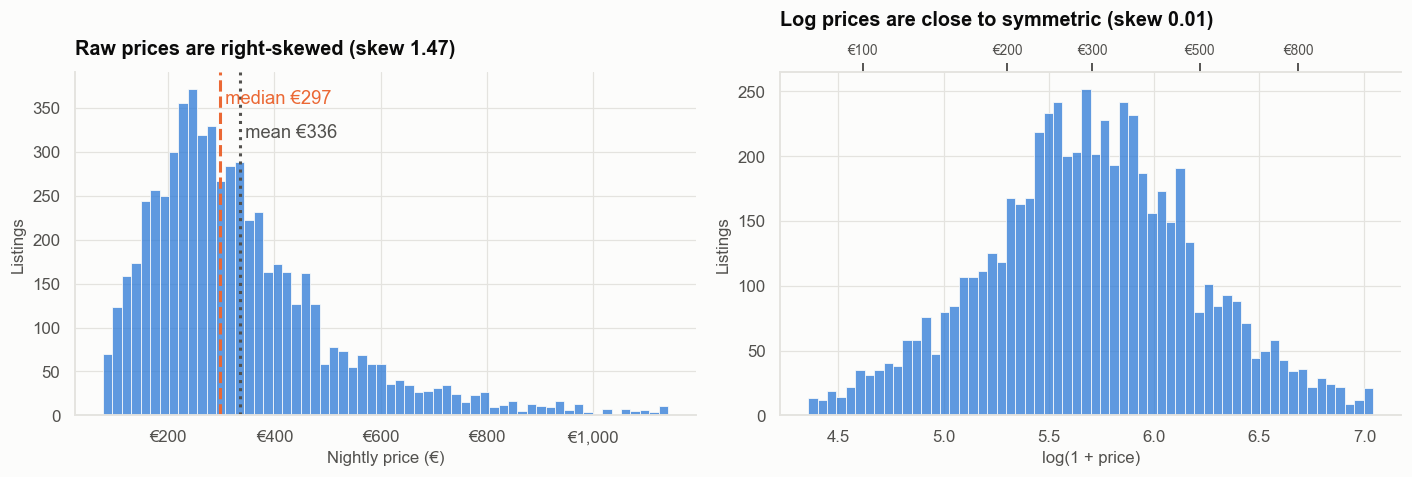

In [4]:
med, mean = df["price"].median(), df["price"].mean()
skew_raw, skew_log = df["price"].skew(), df["log_price"].skew()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.histplot(df["price"], bins=60, color=BLUE, edgecolor=SURFACE, linewidth=0.5, ax=axes[0])
axes[0].axvline(med, color=ORANGE, lw=2, ls="--")
axes[0].axvline(mean, color=TEXT_SECONDARY, lw=2, ls=":")
ymax = axes[0].get_ylim()[1]
axes[0].text(med, ymax * 0.95, f" median €{med:,.0f}", color=ORANGE, va="top")
axes[0].text(mean, ymax * 0.85, f" mean €{mean:,.0f}", color=TEXT_SECONDARY, va="top")
axes[0].xaxis.set_major_formatter(euro)
axes[0].set(title=f"Raw prices are right-skewed (skew {skew_raw:.2f})", xlabel="Nightly price (€)", ylabel="Listings")

sns.histplot(df["log_price"], bins=60, color=BLUE, edgecolor=SURFACE, linewidth=0.5, ax=axes[1])
axes[1].set(title=f"Log prices are close to symmetric (skew {skew_log:.2f})", xlabel="log(1 + price)", ylabel="Listings")
sec = axes[1].secondary_xaxis("top", functions=(np.expm1, np.log1p))
sec.set_xticks([100, 200, 300, 500, 800])
sec.xaxis.set_major_formatter(euro)
sec.tick_params(colors=TEXT_SECONDARY, labelsize=9)
plt.tight_layout()
save_fig(fig, "02_price_distribution")
plt.show()

The mean sits above the median because a tail of premium listings pulls it up. This is why the modelling and statistical tests use **log price** and **medians**.

## 3. Price by room type

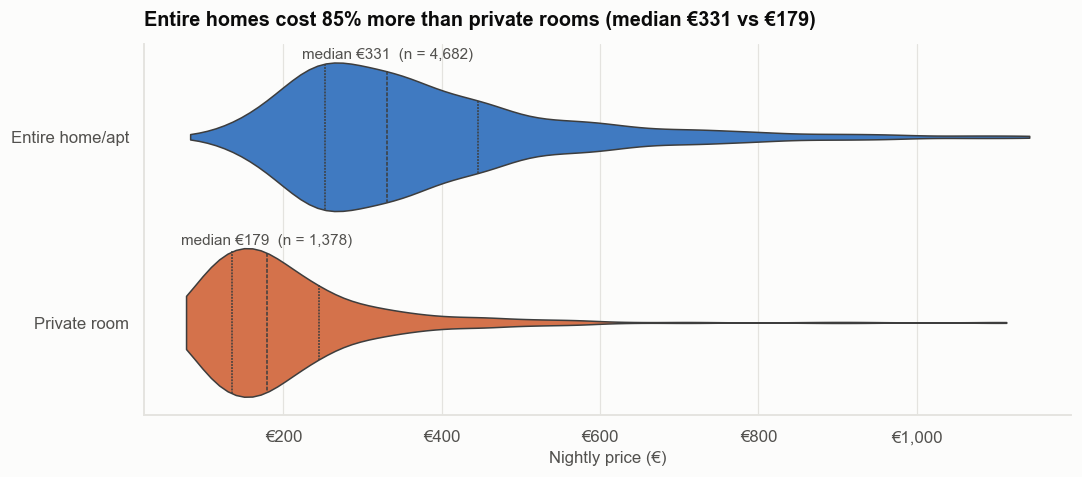

In [5]:
main_rooms = df[df["room_type"].isin(["Entire home/apt", "Private room"])]
room_med = main_rooms.groupby("room_type")["price"].median()
room_n = main_rooms["room_type"].value_counts()
gap = room_med["Entire home/apt"] / room_med["Private room"] - 1

fig, ax = plt.subplots(figsize=(10, 4.5))
order = ["Entire home/apt", "Private room"]
sns.violinplot(data=main_rooms, y="room_type", x="price", order=order, hue="room_type", hue_order=order,
               palette=ROOM_COLORS, inner="quartile", cut=0, linewidth=1, legend=False, ax=ax)
for i, rt in enumerate(order):
    ax.text(room_med[rt], i - 0.42, f"median €{room_med[rt]:,.0f}  (n = {room_n[rt]:,})",
            ha="center", color=TEXT_SECONDARY, fontsize=10)
ax.xaxis.set_major_formatter(euro)
ax.set(title=f"Entire homes cost {gap:.0%} more than private rooms (median €{room_med['Entire home/apt']:,.0f} vs €{room_med['Private room']:,.0f})",
       xlabel="Nightly price (€)", ylabel="")
plt.tight_layout()
save_fig(fig, "02_price_by_room_type")
plt.show()

## 4. Price in the 10 largest neighbourhoods

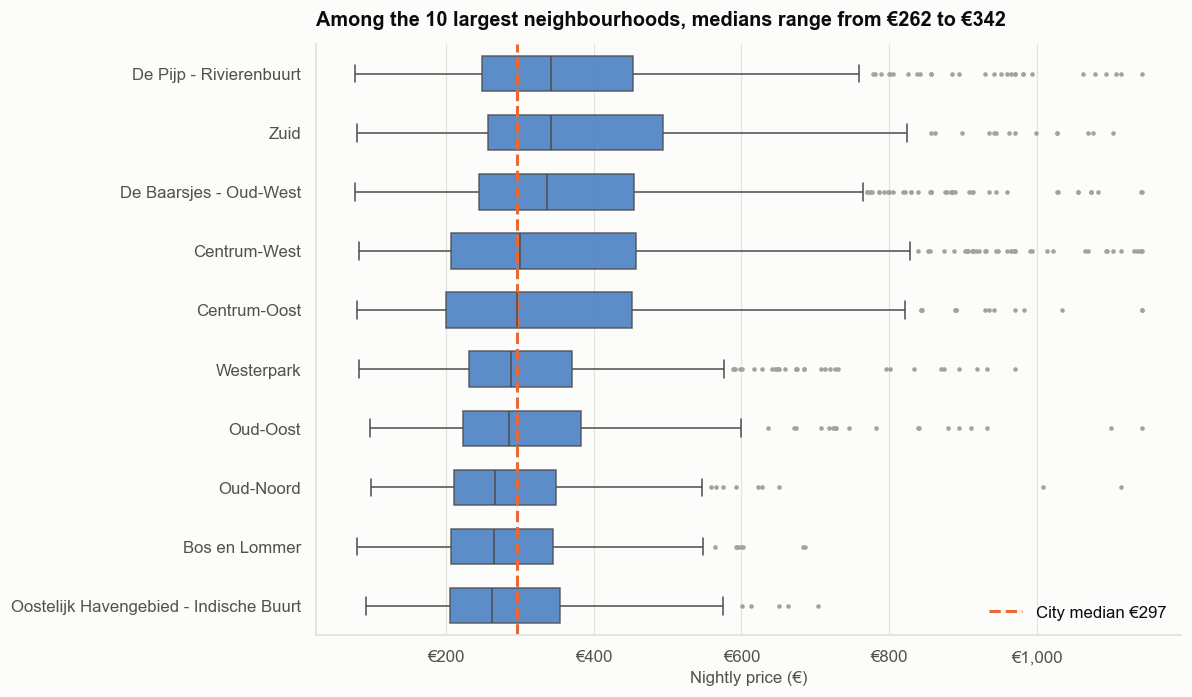

In [6]:
top10 = df["neighbourhood_cleansed"].value_counts().head(10).index
sub = df[df["neighbourhood_cleansed"].isin(top10)]
order = sub.groupby("neighbourhood_cleansed")["price"].median().sort_values(ascending=False).index
top_med = sub.groupby("neighbourhood_cleansed")["price"].median()

fig, ax = plt.subplots(figsize=(11, 6.5))
sns.boxplot(data=sub, y="neighbourhood_cleansed", x="price", order=order, color=BLUE,
            fliersize=2, linewidth=1, width=0.6, boxprops={"alpha": 0.85},
            flierprops={"markerfacecolor": NEUTRAL, "markeredgecolor": NEUTRAL}, ax=ax)
ax.axvline(med, color=ORANGE, ls="--", lw=2, label=f"City median €{med:,.0f}")
ax.legend(loc="lower right")
ax.xaxis.set_major_formatter(euro)
ax.set(title=f"Among the 10 largest neighbourhoods, medians range from €{top_med.min():,.0f} to €{top_med.max():,.0f}",
       xlabel="Nightly price (€)", ylabel="")
plt.tight_layout()
save_fig(fig, "02_price_top10_neighbourhoods")
plt.show()

## 5. Where are the expensive listings? (map)
Each dot is a listing: colour = nightly price (log scale), size = number of reviews. The star marks Dam Square, the historic centre.

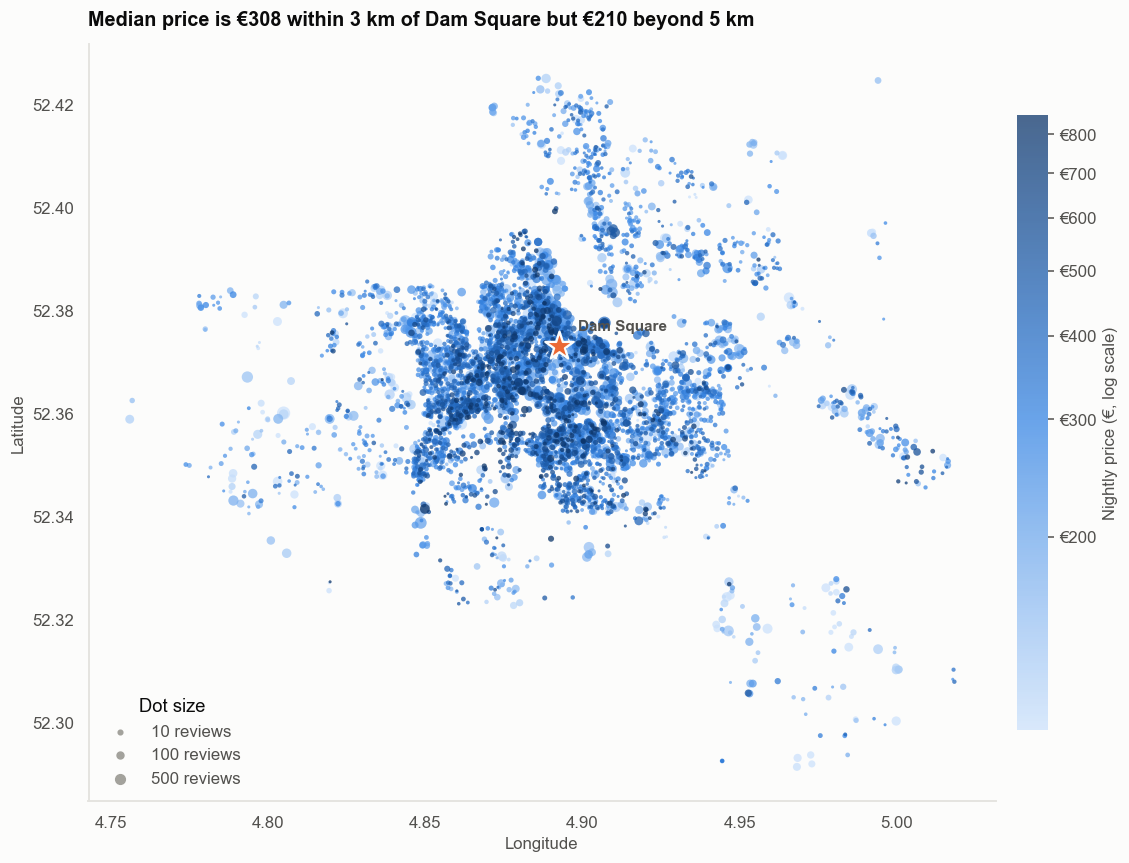

In [7]:
plot_df = df.sort_values("price")  # draw expensive listings last so they sit on top
sizes = 4 + np.sqrt(plot_df["number_of_reviews"]) * 1.6

fig, ax = plt.subplots(figsize=(11, 8.5))
sc = ax.scatter(plot_df["longitude"], plot_df["latitude"], c=plot_df["price"], s=sizes,
                cmap=SEQ_BLUE, norm=LogNorm(vmin=df["price"].quantile(0.02), vmax=df["price"].quantile(0.98)),
                alpha=0.75, linewidths=0)
ax.scatter(4.8926, 52.3731, marker="*", s=380, color=ORANGE, edgecolor=SURFACE, linewidth=1.5, zorder=5)
ax.annotate("Dam Square", (4.8926, 52.3731), xytext=(12, 10), textcoords="offset points",
            color=TEXT_SECONDARY, fontsize=10, fontweight="bold")
cbar = fig.colorbar(sc, ax=ax, shrink=0.7, pad=0.02)
cbar.set_label("Nightly price (€, log scale)", color=TEXT_SECONDARY)
cbar.ax.yaxis.set_major_formatter(euro)
cbar.ax.yaxis.set_minor_formatter(euro)
cbar.outline.set_visible(False)
for n in [10, 100, 500]:
    ax.scatter([], [], s=4 + np.sqrt(n) * 1.6, color=NEUTRAL, label=f"{n} reviews")
ax.legend(title="Dot size", loc="lower left", labelcolor=TEXT_SECONDARY)
ax.set_aspect(1 / np.cos(np.radians(52.37)))
inner = df.loc[df["dist_centre_km"] < 3, "price"].median()
outer = df.loc[df["dist_centre_km"] >= 5, "price"].median()
ax.set(title=f"Median price is €{inner:,.0f} within 3 km of Dam Square but €{outer:,.0f} beyond 5 km",
       xlabel="Longitude", ylabel="Latitude")
ax.grid(False)
plt.tight_layout()
save_fig(fig, "02_price_map")
plt.show()

In [8]:
bands = pd.cut(df["dist_centre_km"], [0, 1, 2, 3, 5, 12], labels=["<1 km", "1–2 km", "2–3 km", "3–5 km", "5+ km"])
dist_tbl = df.groupby(bands, observed=True).agg(listings=("price", "size"), median_price=("price", "median"),
                                                 median_price_per_guest=("price_per_person", "median")).round(0)
dist_tbl

,listings,median_price,median_price_per_guest
dist_centre_km,,,
<1 km,746,295.0,118.0
1–2 km,1490,314.0,122.0
2–3 km,1865,308.0,118.0
3–5 km,1494,286.0,97.0
5+ km,491,210.0,68.0


## 6. Average price by neighbourhood (all 22)

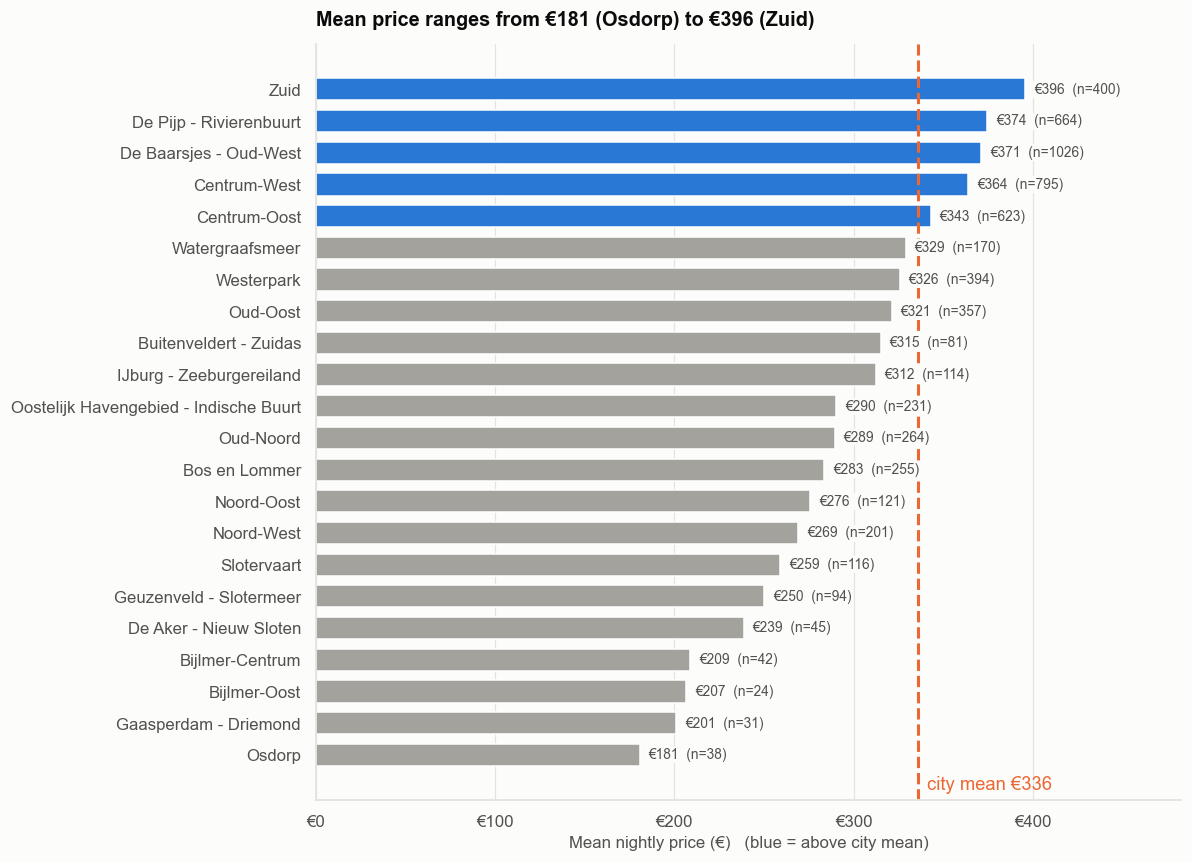

In [9]:
nb = (df.groupby("neighbourhood_cleansed")
        .agg(mean_price=("price", "mean"), median_price=("price", "median"), listings=("price", "size"))
        .sort_values("mean_price"))
city_mean = df["price"].mean()

fig, ax = plt.subplots(figsize=(11, 8))
colors = [BLUE if v >= city_mean else NEUTRAL for v in nb["mean_price"]]
ax.barh(nb.index, nb["mean_price"], color=colors, height=0.7)
for i, (v, n) in enumerate(zip(nb["mean_price"], nb["listings"])):
    ax.text(v + 5, i, f"€{v:,.0f}  (n={n})", va="center", fontsize=9, color=TEXT_SECONDARY, zorder=4,
            bbox={"facecolor": SURFACE, "edgecolor": "none", "pad": 1})
ax.axvline(city_mean, color=ORANGE, ls="--", lw=2, zorder=1)
ax.text(city_mean + 5, -1.1, f"city mean €{city_mean:,.0f}", color=ORANGE)
ax.xaxis.set_major_formatter(euro)
ax.set_xlim(0, nb["mean_price"].max() * 1.22)
ax.set(title=f"Mean price ranges from €{nb['mean_price'].min():,.0f} ({nb.index[0]}) to €{nb['mean_price'].max():,.0f} ({nb.index[-1]})",
       xlabel="Mean nightly price (€)   (blue = above city mean)", ylabel="")
ax.grid(axis="y", visible=False)
plt.tight_layout()
save_fig(fig, "02_avg_price_by_neighbourhood")
plt.show()

In [10]:
nb.sort_values("mean_price", ascending=False).round(0)

,mean_price,median_price,listings
neighbourhood_cleansed,,,
Zuid,396.0,342.0,400
De Pijp - Rivierenbuurt,374.0,342.0,664
De Baarsjes - Oud-West,371.0,337.0,1026
Centrum-West,364.0,300.0,795
Centrum-Oost,343.0,296.0,623
Watergraafsmeer,329.0,300.0,170
Westerpark,326.0,288.0,394
Oud-Oost,321.0,286.0,357
Buitenveldert - Zuidas,315.0,250.0,81


In [11]:
# Numbers used in the takeaways
above = (nb["mean_price"] >= city_mean).sum()
print(f"Median €{med:.0f}, mean €{mean:.0f}; skew raw {skew_raw:.2f} → log {skew_log:.2f}")
print(f"Entire home median €{room_med['Entire home/apt']:.0f} vs private room €{room_med['Private room']:.0f} → +{gap:.1%}")
print(f"{above} of {len(nb)} neighbourhoods are above the city mean")
print(f"Top / bottom mean ratio: {nb['mean_price'].max() / nb['mean_price'].min():.2f}x")
print(f"Share of listings within 3 km of Dam Square: {(df['dist_centre_km'] < 3).mean():.1%}")

Median €297, mean €336; skew raw 1.47 → log 0.01
Entire home median €331 vs private room €179 → +84.8%
5 of 22 neighbourhoods are above the city mean
Top / bottom mean ratio: 2.19x
Share of listings within 3 km of Dam Square: 67.4%


## Key Takeaways

- **Typical price:** median **€297/night** (mean €336, pulled up by a premium tail; skew 1.47 on the raw scale vs 0.01 on the log scale, so we model log price). Median per guest: €110.
- **Room type is the first split:** entire homes (76.9% of listings) have a median of **€331** vs **€179** for private rooms, i.e. **85% more**.
- **Location matters, but "central" is broader than the old town:** median price is €308 within 3 km of Dam Square vs €210 beyond 5 km (**47% higher**). The 1–2 km band (€314) is slightly *above* the <1 km band (€295), because the very centre has more small units and rooms.
- **Neighbourhood spread:** mean price runs from €181 (Osdorp) to €396 (Zuid), a **2.2× gap**. Only 5 of 22 neighbourhoods (Zuid, De Pijp, De Baarsjes–Oud-West, Centrum-West, Centrum-Oost) sit above the city mean of €336.
- **Supply is concentrated:** 67.4% of listings are within 3 km of Dam Square; De Baarsjes–Oud-West alone has 1,026 listings (16.9%).